DATASET OVERVIEW
Customers: 2400 rows, 9 columns
Orders: 10009 rows, 10 columns
Support Tickets: 1921 rows, 8 columns
Web Events: 2400 rows, 10 columns
Churn Labels: 2400 rows, 4 columns
RFM Snapshot: 2400 rows, 29 columns
Interventions: 2400 rows, 5 columns
MISSING VALUES ANALYSIS - customers.csv
      Column  Missing_Count  Missing_Percent
loyalty_tier           1386        57.750000
   skin_type            401        16.708333

LOYALTY_TIER ANALYSIS
loyalty_tier
NaN         1386
Silver       590
Gold         319
Platinum     105
Name: count, dtype: int64

Customers without loyalty tier: 1386 (57.8%)

SKIN_TYPE ANALYSIS
skin_type
Oily           420
Dry            405
NaN            401
Sensitive      395
Combination    390
Normal         389
Name: count, dtype: int64
ORDERS DATA QUALITY
Orders with _DUP suffix: 12
Post-snapshot orders (NOT for features): 1872

Gross Amount Statistics:
count    10009.000000
mean       743.898504
std        600.564068
min        149.000000
25%        4

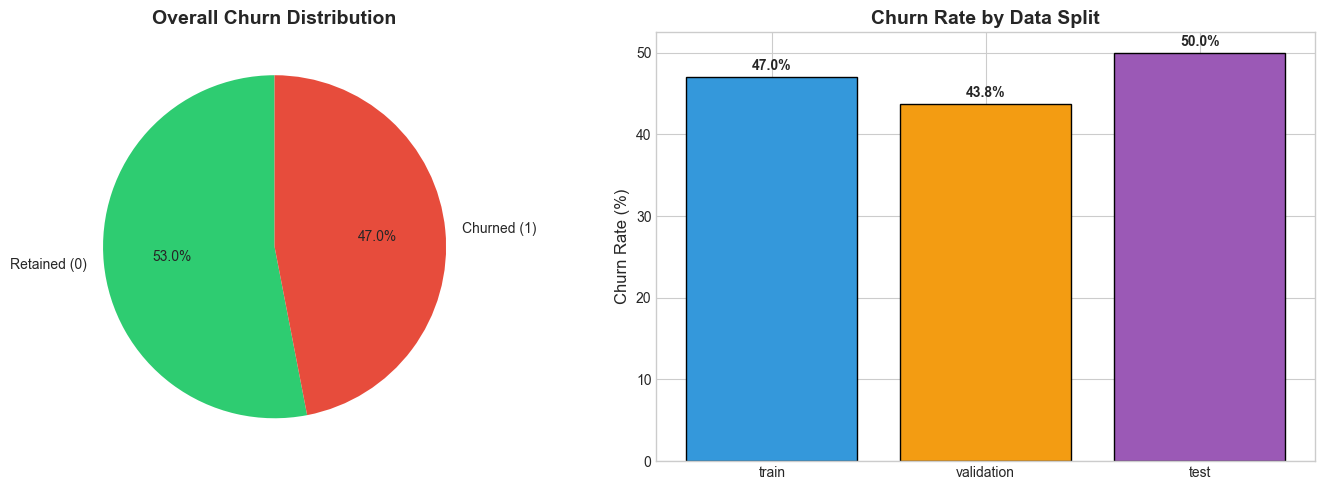

TEMPORAL ANALYSIS
Churn Rate by Signup Month:
              Signups  Churn_Rate
signup_month                     
2024-01           116   49.137931
2024-02           106   51.886792
2024-03           120   55.000000
2024-04           124   47.580645
2024-05           117   45.299145
2024-06           125   47.200000
2024-07           121   56.198347
2024-08           114   42.982456
2024-09           111   49.549550
2024-10           133   57.894737
2024-11           127   51.181102
2024-12           116   49.137931
2025-01           127   51.181102
2025-02           104   57.692308
2025-03           112   48.214286
2025-04           110   53.636364
2025-05           114   49.122807
2025-06           100   38.000000
2025-07           116   31.034483
2025-08           120   26.666667
2025-09            67   10.447761

CHURN BY ACQUISITION CHANNEL
                     Total  Churn_Rate
acquisition_channel                   
Google Search          466   50.429185
Instagram              51

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


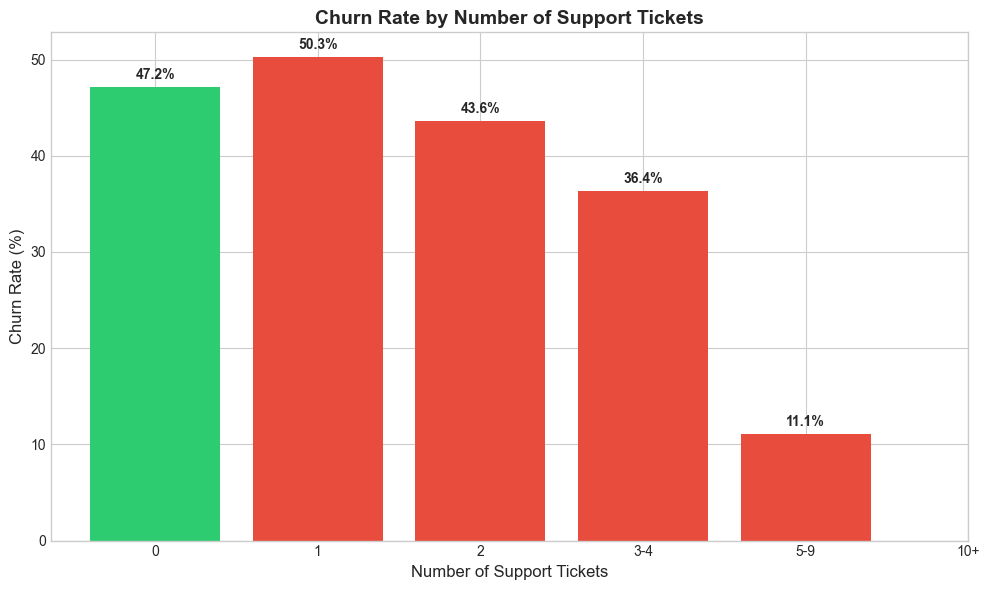


TICKET SENTIMENT ANALYSIS
Avg sentiment score - Retained customers: -0.436
Avg sentiment score - Churned customers: -0.447
WEB ACTIVITY ANALYSIS

Web Metrics Comparison (Churned vs Retained):
--------------------------------------------------
sessions_30d              | Retained:     6.73 | Churned:     4.02
product_views_30d         | Retained:    28.38 | Churned:    16.97
cart_adds_30d             | Retained:     1.95 | Churned:     1.13
wishlist_adds_30d         | Retained:     1.06 | Churned:     0.59
abandoned_carts_30d       | Retained:     0.85 | Churned:     0.47
email_opens_30d           | Retained:     2.95 | Churned:     2.30
campaign_clicks_30d       | Retained:     0.74 | Churned:     0.55
last_visit_days_ago       | Retained:     9.77 | Churned:    26.55


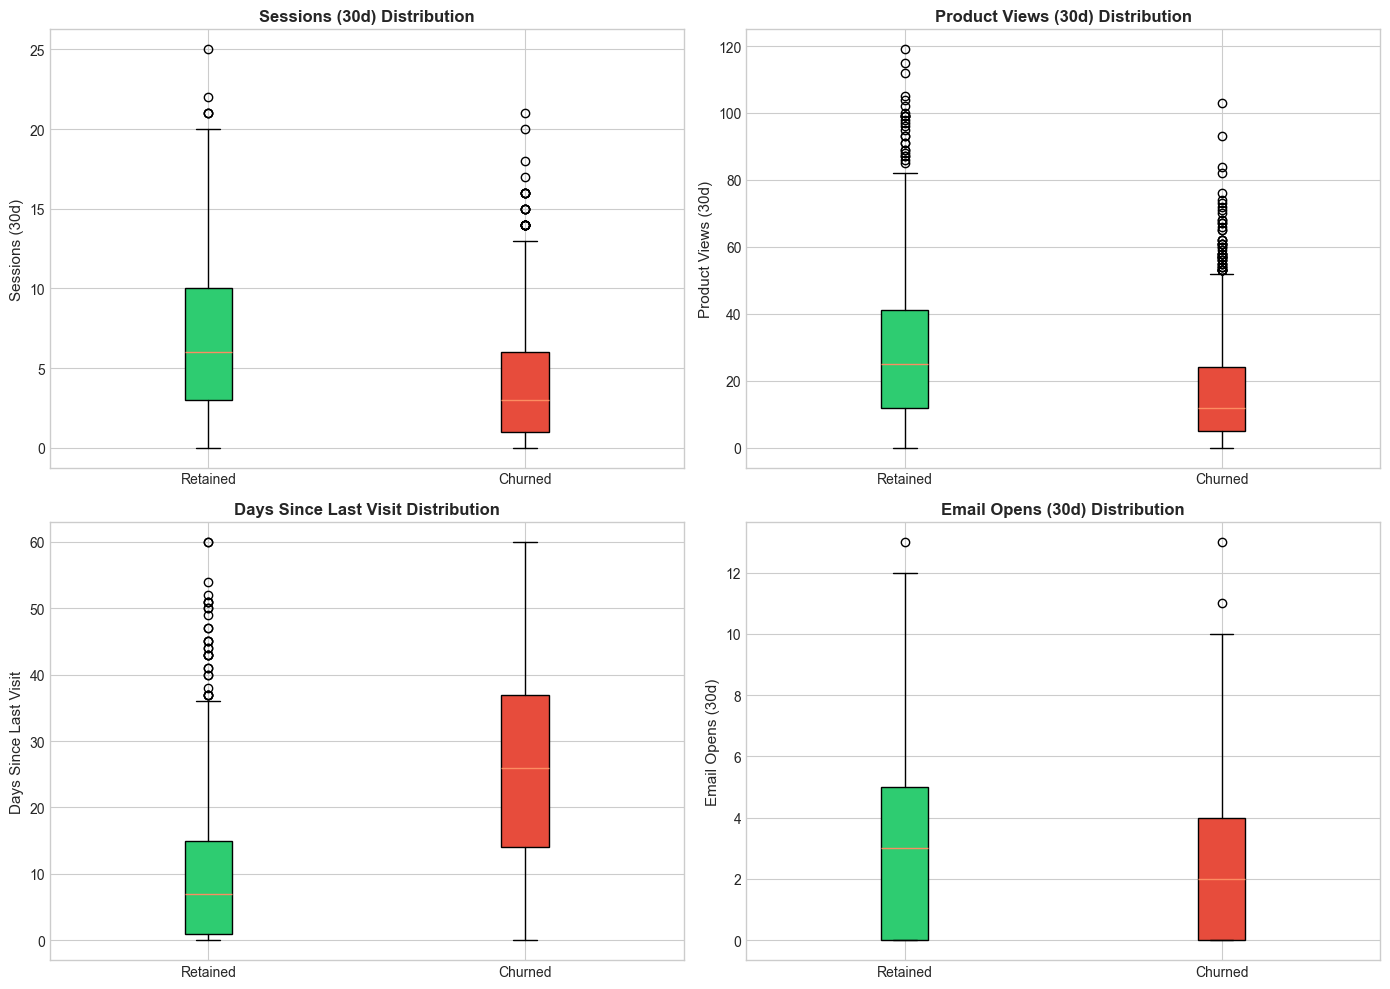

KEY BUSINESS INSIGHTS

Churn Rate:
  → 47.0% of customers churned in the 60-day window

Support Impact:
  → Customers with tickets churn at 46.8% vs 47.2% without tickets

Sentiment:
  → Churned customers had 0.010 lower average sentiment score

Recency:
  → Churned customers last visited 27 days ago vs 10 days for retained

Best Channel:
  → Lowest churn channel: Organic (39.8%)

Worst Channel:
  → Highest churn channel: Google Search (50.4%)
RFM SEGMENTATION ANALYSIS

RFM Score Distribution:
R_score  F_score  M_score
1        1        1          105
                  2           42
                  3            4
         2        1           38
                  2           97
                  3           33
                  4            5
         3        2           44
                  3           83
                  4           33
         4        2            2
                  3           33
                  4           81
2        1        1           95
             

KeyError: 'segment'

RFM SEGMENTATION ANALYSIS
RFM DataFrame shape: (2400, 4)
Customers with no orders: 0

RFM Score Distribution:
R_score  F_score  M_score
1        1        1          105
                  2           42
                  3            4
         2        1           38
                  2           97
                  3           33
                  4            5
         3        2           44
                  3           83
                  4           33
Name: count, dtype: int64

SEGMENT DISTRIBUTION
segment
Potential    1004
At Risk       600
Champions     531
Loyal         265
Name: count, dtype: int64

Segment Percentages:
  Potential: 41.8%
  At Risk: 25.0%
  Champions: 22.1%
  Loyal: 11.0%

CHURN RATE BY SEGMENT
  Champions: 13.7%
  Loyal: 21.5%
  Potential: 45.9%
  At Risk: 89.3%


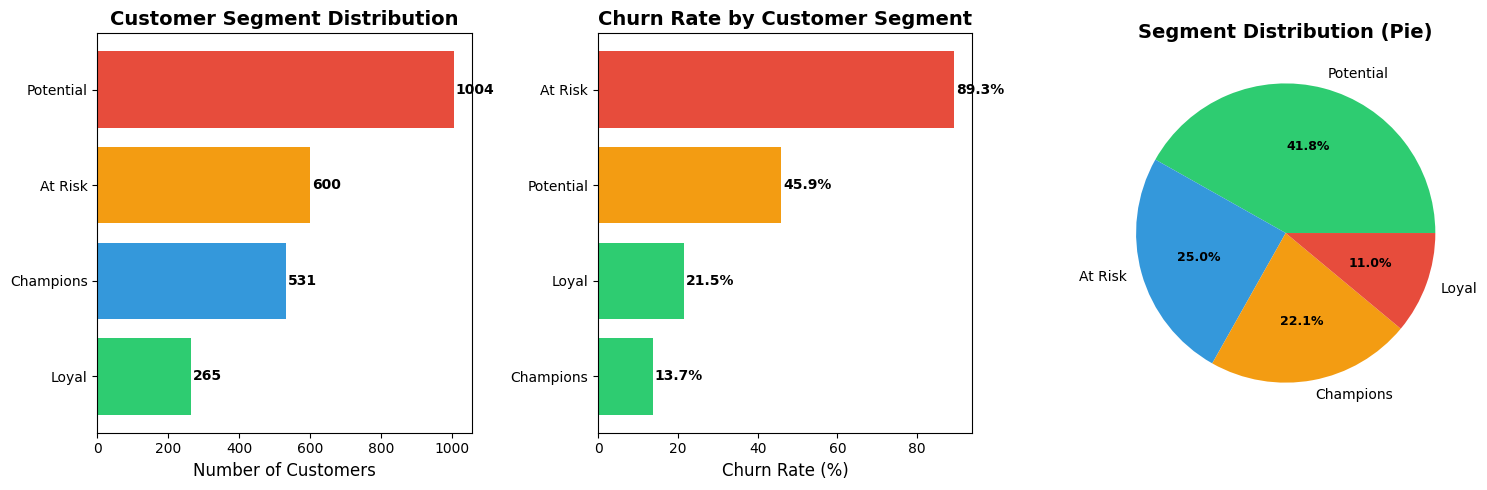


✅ Customer segments exported to 'customer_segments.csv'

RETENTION STRATEGY RECOMMENDATIONS

SEGMENT: CHAMPIONS
Customers: 531 (22.1%)
Churn Rate: 13.7%
Actions: VIP loyalty program, Early access to new products, Premium support
Budget Priority: Low
Expected Impact: Maintain high LTV

SEGMENT: LOYAL
Customers: 265 (11.0%)
Churn Rate: 21.5%
Actions: Loyalty rewards, Personalized recommendations, Exclusive offers
Budget Priority: Medium
Expected Impact: Increase frequency

SEGMENT: POTENTIAL
Customers: 1004 (41.8%)
Churn Rate: 45.9%
Actions: Engagement emails, 15% discount offers, Cross-selling
Budget Priority: Medium
Expected Impact: Convert to loyal

SEGMENT: AT RISK
Customers: 600 (25.0%)
Churn Rate: 89.3%
Actions: Urgent win-back campaign, 20-25% discount, Proactive support
Budget Priority: High
Expected Impact: Reduce churn


In [1]:
# ===================================================================
# PART 2: RFM SEGMENTATION - COMPLETE FIXED CODE
# ===================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*60)
print("RFM SEGMENTATION ANALYSIS")
print("="*60)

# Load data
customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
support_tickets = pd.read_csv("data/support_tickets.csv")
web_events = pd.read_csv("data/web_events_snapshot.csv")
churn_labels = pd.read_csv("data/churn_labels.csv")
rfm_snapshot = pd.read_csv("data/rfm_modeling_snapshot.csv")
intervention = pd.read_csv("data/intervention_history.csv")
# Filter pre-snapshot orders only
snapshot_date = pd.to_datetime('2025-09-30')
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders_pre = orders[orders['order_date'] <= snapshot_date].copy()

# ===================================================================
# STEP 1: Calculate RFM Metrics
# ===================================================================

# Calculate RFM metrics per customer
rfm = orders_pre.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',  # Frequency
    'gross_amount': 'sum'  # Monetary
}).rename(columns={
    'order_date': 'recency_days',
    'order_id': 'frequency',
    'gross_amount': 'monetary'
})

# Handle customers with no orders
all_customers = pd.DataFrame({'customer_id': customers['customer_id'].unique()})
rfm = all_customers.merge(rfm, on='customer_id', how='left')

# Fill NaN values
rfm['recency_days'] = rfm['recency_days'].fillna(999)  # Very high recency for no purchases
rfm['frequency'] = rfm['frequency'].fillna(0)
rfm['monetary'] = rfm['monetary'].fillna(0)

print(f"RFM DataFrame shape: {rfm.shape}")
print(f"Customers with no orders: {(rfm['frequency'] == 0).sum()}")

# ===================================================================
# STEP 2: Calculate RFM Scores
# ===================================================================

def calculate_score(series, ascending=True):
    """
    Calculate quartile-based scores (1-4)
    ascending=True: lower values get higher scores (for Recency)
    ascending=False: higher values get higher scores (for Frequency, Monetary)
    """
    # Handle case where all values are the same or series is empty
    if series.nunique() <= 1:
        return pd.Series([2] * len(series), index=series.index)
    
    try:
        if ascending:
            # For recency: lower is better (4 = best)
            return pd.qcut(series.rank(method='first'), q=4, labels=[4, 3, 2, 1], duplicates='drop').astype(int)
        else:
            # For frequency and monetary: higher is better (4 = best)
            return pd.qcut(series.rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)
    except Exception as e:
        print(f"Error in calculate_score: {e}")
        # Fallback: simple ranking
        return pd.qcut(series, q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)

# Calculate scores
# For Recency: lower days = better score (4 = best)
rfm['R_score'] = 1  # Default for no orders
mask_has_orders = rfm['frequency'] > 0

if mask_has_orders.any():
    rfm.loc[mask_has_orders, 'R_score'] = calculate_score(
        rfm.loc[mask_has_orders, 'recency_days'], ascending=True
    )

# For Frequency: higher count = better score
rfm['F_score'] = calculate_score(rfm['frequency'], ascending=False)

# For Monetary: higher spend = better score
rfm['M_score'] = calculate_score(rfm['monetary'], ascending=False)

# ===================================================================
# STEP 3: Create RFM Segment
# ===================================================================

# Create combined RFM segment
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Add churn labels
rfm = rfm.merge(churn_labels[['customer_id', 'churn_next_60d']], on='customer_id', how='left')

print("\nRFM Score Distribution:")
print(rfm[['R_score', 'F_score', 'M_score']].value_counts().sort_index().head(10))

# ===================================================================
# STEP 4: Assign Customer Segments
# ===================================================================

def assign_segment(row):
    """Assign customer segment based on RFM scores"""
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    
    # Champions: High recency, high frequency, high monetary
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    # Loyal: Good recency and frequency
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Loyal'
    # Potential: Moderate scores
    elif r >= 2 and f >= 1 and m >= 1:
        return 'Potential'
    # At Risk: Poor recency but has purchased before
    elif r == 1 and f >= 1:
        return 'At Risk'
    # Hibernating: Poor recency and low frequency
    elif r == 1 and f == 0:
        return 'Hibernating'
    # New or Unknown
    else:
        return 'New'

# Apply segment assignment
rfm['segment'] = rfm.apply(assign_segment, axis=1)

# ===================================================================
# STEP 5: Segment Distribution (FIXED)
# ===================================================================

# THIS IS THE FIXED SECTION
segment_dist = rfm['segment'].value_counts()
print("\n" + "="*60)
print("SEGMENT DISTRIBUTION")
print("="*60)
print(segment_dist)

# Segment percentages
segment_pct = (segment_dist / len(rfm) * 100).round(1)
print("\nSegment Percentages:")
for seg, pct in segment_pct.items():
    print(f"  {seg}: {pct}%")

# ===================================================================
# STEP 6: Churn Rate by Segment
# ===================================================================

segment_churn = rfm.groupby('segment')['churn_next_60d'].mean() * 100
segment_churn = segment_churn.sort_values()

print("\n" + "="*60)
print("CHURN RATE BY SEGMENT")
print("="*60)
for seg, rate in segment_churn.items():
    print(f"  {seg}: {rate:.1f}%")

# ===================================================================
# STEP 7: Visualization
# ===================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Segment Distribution - Bar Chart
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
segment_dist_sorted = segment_dist.sort_values(ascending=True)
bars = axes[0].barh(segment_dist_sorted.index, segment_dist_sorted.values, color=colors)
axes[0].set_xlabel('Number of Customers', fontsize=12)
axes[0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, segment_dist_sorted.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
                 str(count), va='center', fontweight='bold')

# 2. Churn Rate by Segment - Bar Chart
segment_churn_sorted = segment_churn.sort_values()
colors_churn = ['#e74c3c' if rate > 50 else '#f39c12' if rate > 30 else '#2ecc71' for rate in segment_churn_sorted.values]
bars = axes[1].barh(segment_churn_sorted.index, segment_churn_sorted.values, color=colors_churn)
axes[1].set_xlabel('Churn Rate (%)', fontsize=12)
axes[1].set_title('Churn Rate by Customer Segment', fontsize=14, fontweight='bold')
for bar, rate in zip(bars, segment_churn_sorted.values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{rate:.1f}%', va='center', fontweight='bold')

# 3. Segment Distribution - Pie Chart
colors_pie = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
wedges, texts, autotexts = axes[2].pie(segment_dist.values, 
                                         labels=segment_dist.index,
                                         autopct='%1.1f%%', 
                                         colors=colors_pie,
                                         textprops={'fontsize': 10})
axes[2].set_title('Segment Distribution (Pie)', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================================
# STEP 8: Export Results
# ===================================================================

# Export segments
segment_export = rfm[['customer_id', 'segment', 'R_score', 'F_score', 'M_score', 
                       'recency_days', 'frequency', 'monetary']]
segment_export.to_csv('customer_segments.csv', index=False)
print("\n" + "="*60)
print("✅ Customer segments exported to 'customer_segments.csv'")
print("="*60)

# ===================================================================
# STEP 9: Retention Strategy Recommendations
# ===================================================================

print("\n" + "="*60)
print("RETENTION STRATEGY RECOMMENDATIONS")
print("="*60)

strategies = {
    'Champions': {
        'actions': ['VIP loyalty program', 'Early access to new products', 'Premium support'],
        'budget': 'Low',
        'impact': 'Maintain high LTV'
    },
    'Loyal': {
        'actions': ['Loyalty rewards', 'Personalized recommendations', 'Exclusive offers'],
        'budget': 'Medium',
        'impact': 'Increase frequency'
    },
    'Potential': {
        'actions': ['Engagement emails', '15% discount offers', 'Cross-selling'],
        'budget': 'Medium',
        'impact': 'Convert to loyal'
    },
    'At Risk': {
        'actions': ['Urgent win-back campaign', '20-25% discount', 'Proactive support'],
        'budget': 'High',
        'impact': 'Reduce churn'
    },
    'Hibernating': {
        'actions': ['Re-engagement campaign', '25% discount', 'Retargeting ads'],
        'budget': 'High',
        'impact': 'Reactivate dormant'
    },
    'New': {
        'actions': ['Welcome series', 'Onboarding', 'Product education'],
        'budget': 'Low',
        'impact': 'Establish relationship'
    }
}

for segment, strategy in strategies.items():
    if segment in segment_dist.index:
        count = segment_dist[segment]
        pct = segment_pct[segment]
        churn = segment_churn.get(segment, 0)
        print(f"\n{'='*50}")
        print(f"SEGMENT: {segment.upper()}")
        print(f"{'='*50}")
        print(f"Customers: {count} ({pct:.1f}%)")
        print(f"Churn Rate: {churn:.1f}%")
        print(f"Actions: {', '.join(strategy['actions'])}")
        print(f"Budget Priority: {strategy['budget']}")
        print(f"Expected Impact: {strategy['impact']}")